In [1]:
from analysis import *

In [91]:
from pathlib import Path

filename="../results_final/slow/slow_instance.out"

all_events = []
dumps = []

with open(filename) as f:
    for line in f:
        if "DUMP" in line: 
            dumps.append(line)
        else:
            all_events.append(parse_line(line))
        
all_events = sorted(all_events, key=lambda x: x['time'])
    

In [92]:
# Find the first repair start after 10 seconds and its corresponding repair end. Get the events for the surrounding 1 seconds

start_time = all_events[0]['time'] + datetime.timedelta(seconds=5)


repairs = list(filter(lambda x: x['time'] > start_time and ('replica_id' in x and x['replica_id'] == 0) and (x['event'] == "repair_start" or x['event'] == "repair_end"), all_events))

repair_start_time = repairs[0]["time"] 
repair_end_time = repairs[1]["time"]
start_time = repair_start_time - datetime.timedelta(seconds=0.6)
end_time = repair_end_time + datetime.timedelta(seconds=0.6)

print(repairs[0]["round"])


slow_path = list(filter(lambda x: x['time'] > start_time and x['time'] < end_time, all_events))

for e in slow_path:
    e['t'] = (e['time'] - repair_start_time).total_seconds()

1


In [93]:
# Find divergence point

spec_executes = list(filter(lambda x: x['time'] > start_time and x['event'] == 'spec_execute' and x['time'] < repair_end_time, slow_path))
seqs = {}
for x in spec_executes:
    if x['seq'] not in seqs:
        seqs[x['seq']] = []
        
    seqs[x['seq']].append(x)
    

dseq = 0
for s in seqs:
    es = seqs[s]

    
    if len(set(x['digest'] for x in es)) > 3:
        dseq = s
        break        

assert(dseq != 0)

In [94]:
dseq
div_t = next(filter(lambda x: x['seq'] == dseq, spec_executes))['t']
div_t

-0.104517

In [95]:
# Find each repair event on replica 0
starts = [x for x in slow_path if x["event"] == 'repair_start']
props = [x for x in slow_path if x["event"] == 'repair_proposal']
prop_recv = [x for x in slow_path if x["event"] == 'repair_preprepare']
preps = [x for x in slow_path if x["event"] == 'prepared']
commits = [x for x in slow_path if x["event"] == 'repair_commit']

print([x["t"] for x in starts])
print([x["t"] for x in props])
print([x["t"] for x in prop_recv])
print([x["t"] for x in preps])
print([x["t"] for x in commits])


[-0.003956, -0.003261, 0.0, 0.0, 0.000605, 0.010425]
[0.30858]
[0.379157, 0.42581, 0.587734, 0.594557, 0.791056, 0.842731]
[0.880439, 0.900678, 0.901633, 0.902546, 0.902577, 0.924337]
[0.914605, 0.91472, 0.915665, 0.915917, 0.932163, 0.933735, 0.93463]


In [96]:
print((repair_end_time- repair_start_time).total_seconds())

0.994737


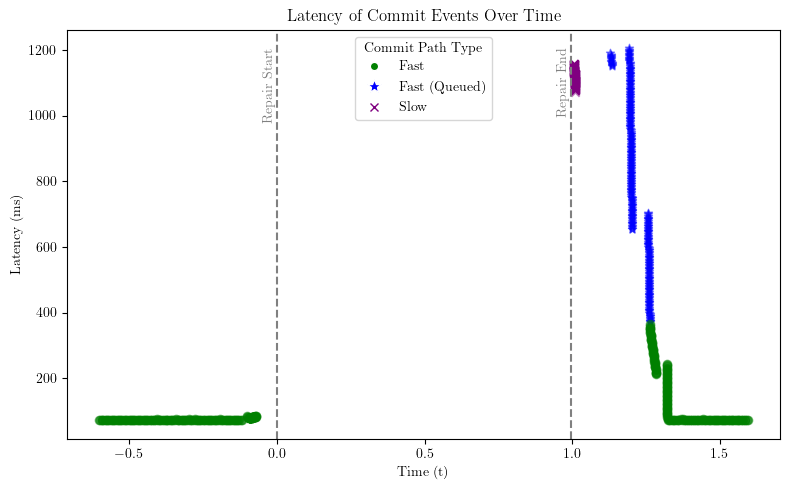

In [97]:
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D
# Filter commit events
commit_events = [e for e in slow_path if e["event"] == "commit" and e["client_id"] == 0]

# Extract data
ts = np.array([e["t"] for e in commit_events]) 
latencies = np.array([e["latency"] for e in commit_events]) / 1000

def commit_color(e):
    if e["path"] == "fast":
        return "blue" if e["queued"] == 1 else "g"
    else:
        return "purple"

def commit_marker(e):
    if e["path"] == "fast":
        return "*" if e["queued"] == 1 else "o"
    else:
        return "x"

colors = np.array([commit_color(e) for e in commit_events])
markers = [commit_marker(e) for e in commit_events]

# Create the scatter plot
plt.figure(figsize=(8, 5))

for (t, l, c, m) in zip(ts, latencies, colors, markers):
    plt.scatter(t, l, c=c, marker=m, alpha=0.5)

# Labels and title
plt.xlabel("Time (t)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Events Over Time")

plt.axvline(x=0, color='gray', linestyle='--')
plt.text(-0.005, max(latencies), 'Repair Start', color='gray', rotation=90, va='top', ha='right')

t_end = (repair_end_time- repair_start_time).total_seconds()
plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end - 0.005, max(latencies), 'Repair End', color='gray', rotation=90, va='top', ha='right')



legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Fast', markerfacecolor='green' ),
    Line2D([0], [0], marker='*', color='w', label='Fast (Queued)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='x', color='purple', label='Slow', linestyle='None' ),
]

plt.legend(handles=legend_elements, loc="upper center", title='Commit Path Type')


plt.tight_layout()
plt.show()



0.6398400000000001
0.6375650000000002


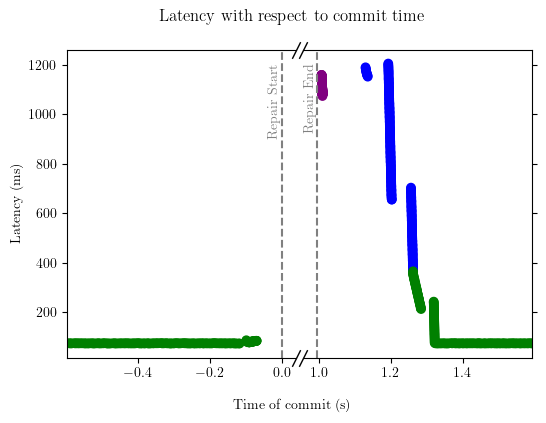

In [98]:
t_left_br = 0.04
t_right_br =  (repair_end_time - repair_start_time).total_seconds() - 0.04
left_mask = ts < t_left_br
right_mask = ts > t_right_br

# Define left and right data ranges
left_range =  t_left_br - (min(ts))
right_range = (max(ts)) - t_right_br

print(left_range)
print(right_range)

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(6, 4),
         gridspec_kw={'width_ratios': [left_range, right_range]})
fig.subplots_adjust(wspace=0.03)  # adjust space between Axes

# Plot left and right ranges
ax1.scatter(ts[left_mask], latencies[left_mask], c=colors[left_mask])
ax2.scatter(ts[right_mask], latencies[right_mask], c=colors[right_mask])

# Set limits
ax1.set_xlim(min(ts) - 0.00005, t_left_br)
ax2.set_xlim(t_right_br, max(ts) + 0.00005)
ax1.set_ylabel("Latency (ms)")
fig.text(0.5, -0.02, 'Time of commit (s)', ha='center')

# hide the spines between ax and ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()
ax2.tick_params(labelleft=False)  # Don't show duplicate labels


d = 2  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)


ax1.axvline(x=0, color='gray', linestyle='--')
ax1.text(-0.005, max(latencies), 'Repair Start', color='gray', rotation=90, va='top', ha='right')

t_end = (repair_end_time- repair_start_time).total_seconds()
ax2.axvline(x=t_end, color='gray', linestyle='--')
ax2.text(t_end - 0.005, max(latencies), 'Repair End', color='gray', rotation=90, va='top', ha='right')


plt.suptitle("Latency with respect to commit time")
plt.show()

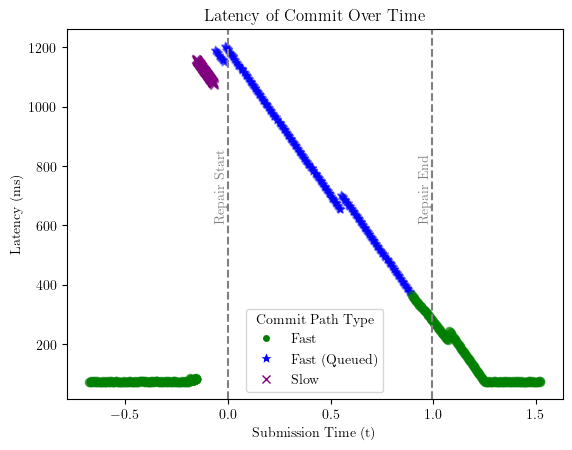

In [99]:

plt.axvline(x=0, color='gray', linestyle='--')
plt.text(-0.005, max(latencies) /2, 'Repair Start', color='gray', rotation=90, va='bottom', ha='right')

t_end = (repair_end_time- repair_start_time).total_seconds()
plt.axvline(x=t_end, color='gray', linestyle='--')
plt.text(t_end - 0.005, max(latencies) / 2, 'Repair End', color='gray', rotation=90, va='bottom', ha='right')


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Fast', markerfacecolor='green' ),
    Line2D([0], [0], marker='*', color='w', label='Fast (Queued)', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], marker='x', color='purple', label='Slow', linestyle='None' ),
]

plt.legend(handles=legend_elements, loc="lower center", title='Commit Path Type')


plt.xlabel("Submission Time (t)")
plt.ylabel("Latency (ms)")
plt.title("Latency of Commit Over Time")


for (t, l, c, m) in zip(ts, latencies, colors, markers):
    plt.scatter(t - l/1000, l , c=c, marker=m, alpha=0.5)

plt.savefig("slow_path_instance")


In [100]:
events = list(filter(lambda x: x['time'] > start_time and x['time'] < end_time, all_events))
commits = list(filter(lambda x: x["event"] == "commit", events))

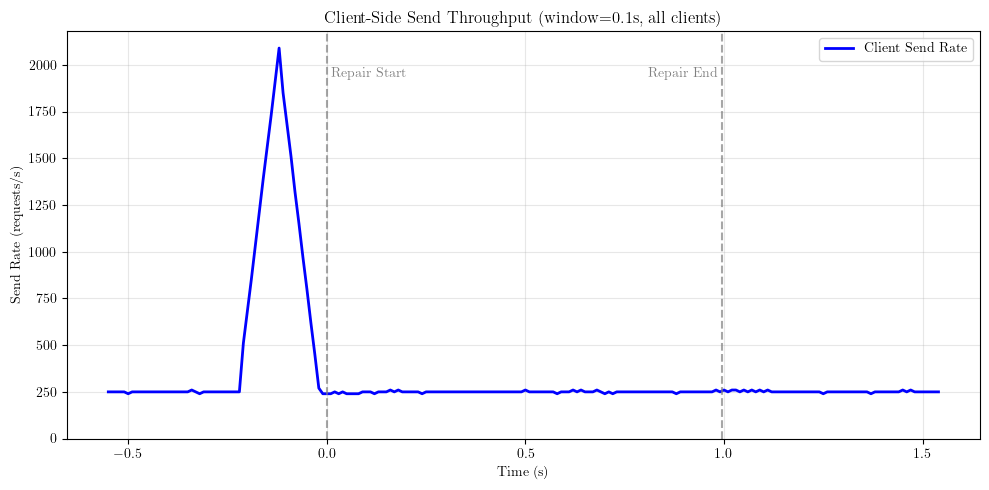

Total sends from clients: 734
Average send rate: 431.76 requests/s
Peak send rate: 2090.00 requests/s
Min send rate: 240.00 requests/s


In [101]:
# Client-side throughput based on send events
# Calculate throughput based on when clients send requests


send_events = list(filter(lambda x: x['time'] < end_time, all_events))

# Filter send events from clients
client_sends = list(filter(lambda x: x["event"] == "send", send_events))

# Optional: Filter for specific client (e.g., client_id == 0)
client_sends = list(filter(lambda x: x["event"] == "send" and x["client_id"] == 0, events))

# Sort by time
client_sends = sorted(client_sends, key=lambda x: x["time"])

# Calculate relative time
for c in client_sends:
    c["t"] = (c["time"] - repair_start_time).total_seconds()

# Calculate throughput using sliding window
w_size_client = 0.1  # window size in seconds
resolution_client = 0.01  # resolution in seconds

end_client = 1.6 + w_size_client

w_start = -0.6
i = 0
j = 0

client_send_counts = []
client_times = []

while w_start + w_size_client < end_client - w_size_client:
    # Find sends in current window
    while i < len(client_sends) and client_sends[i]["t"] < w_start:
        i += 1
    while j < len(client_sends) and client_sends[j]["t"] <= w_start + w_size_client:
        j += 1
    
    client_send_counts.append(j - i)
    client_times.append(w_start + w_size_client/2)  # Use end of window for plotting
    
    w_start += resolution_client

client_send_throughput = np.array(client_send_counts) / w_size_client

# Plot client-side send throughput
plt.figure(figsize=(10, 5))
plt.plot(client_times, client_send_throughput, label='Client Send Rate', linewidth=2, color='blue')

# Add repair markers
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
plt.text(0.01, max(client_send_throughput) * 0.95, 'Repair Start', color='gray', rotation=0, va='top', ha='left')

t_end = (repair_end_time - repair_start_time).total_seconds()
plt.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7)
plt.text(t_end - 0.01, max(client_send_throughput) * 0.95, 'Repair End', color='gray', rotation=0, va='top', ha='right')

plt.title(f'Client-Side Send Throughput (window={w_size_client}s, all clients)')
plt.xlabel('Time (s)')
plt.ylabel(f'Send Rate (requests/s)')
plt.legend()
plt.ylim(0, None)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
total_sends = len(client_sends)
total_time = end_client
avg_send_rate = total_sends / total_time if total_time > 0 else 0
print(f"Total sends from clients: {total_sends}")
print(f"Average send rate: {avg_send_rate:.2f} requests/s")
print(f"Peak send rate: {max(client_send_throughput):.2f} requests/s")
print(f"Min send rate: {min(client_send_throughput):.2f} requests/s")

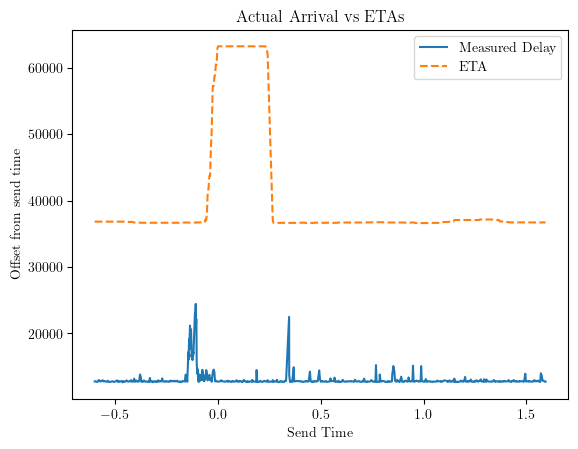

In [102]:
# Plot delay offset

receives = list(filter(lambda x: x['event'] == "receive" and x["c_id"] == 1 and x["replica_id"] == 0, events))

times = [(x['time'] - repair_start_time).total_seconds() for i, x in enumerate(receives) ]
offsets = [x["delay"] for i, x in enumerate(receives)]
deadlines = [x["deadline_offset"] for i, x in enumerate(receives)]

plt.plot(times, offsets, label='Measured Delay')
plt.plot(times, deadlines, label='ETA', linestyle="--")


plt.title('Actual Arrival vs ETAs')
plt.xlabel('Send Time')
plt.ylabel(f'Offset from send time')
plt.legend()

plt.ylim(None, None)
plt.savefig("delay")
plt.show()

In [103]:
import matplotlib

# matplotlib.use("pgf")

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

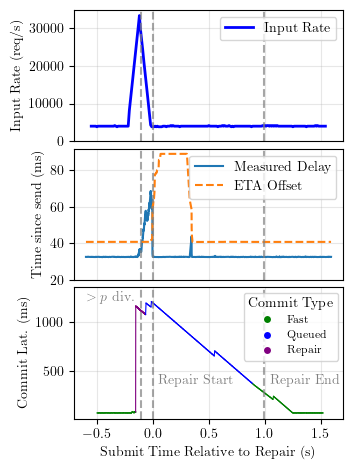

In [106]:
# Combined plot with shared x-axis - last 3 plots
# Rearranged to have the commit latency at the bottom
fig, (ax2, ax3, ax1) = plt.subplots(3, 1, figsize=(3.333, 4.5), sharex=True)
# fig.subplots_adjust(hspace=0)  # Compress spacing between plots

# Plot 1: Latency of Commit Events 
prev_x = None
prev_y = None
prev_color = None

for (t, l, c, m) in zip(ts, latencies, colors, markers):
    x = t - l/1000

    # Only draw points in your window
    if x > -0.5:
        # Scatter point
        # ax1.scatter(x, l, c=c, marker=None, alpha=0.5, s=2)

        # If we have a previous point, draw a segment
        if prev_x is not None:
            # Use *current* point’s color for the segment
            ax1.plot(
                [prev_x, x],
                [prev_y, l],
                color=c,
                linewidth=0.8
            )

        # Update previous point
        prev_x = x
        prev_y = l
        prev_color = c

ax1.set_ylabel("Commit Lat. (ms)")
# ax1.set_title("Latency of Commit Over Time")
ax1.axvline(x=div_t, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Fast', markerfacecolor='green'),
    Line2D([0], [0], marker='o', color='w', label='Queued', markerfacecolor='blue'),
    Line2D([0], [0], marker='o', color='w', label='Repair', markerfacecolor='purple'),
]
ax1.legend(handles=legend_elements, loc="upper right", title='Commit Type', fontsize=8)
ax1.set_ylim(None, 1350)
ax1.grid(True, alpha=0.3)


# Plot 2: Client Send Rate 
ax2.plot(client_times, client_send_throughput * 16, linewidth=2, label="Input Rate", color='blue')
ax2.set_ylabel(f'Input Rate (req/s)')
# ax2.set_title(f'Client-Side Send Throughput (window={w_size_client}s)')
ax2.axvline(x=div_t, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7)
ax2.set_ylim(0, None)
ax2.grid(True, alpha=0.3)
ax2.legend()


# Plot 3: Actual Arrival vs ETAs 
receives_plot = list(filter(lambda x: x['event'] == "receive" and x["c_id"] == 2 and x["replica_id"] == 0, events))
times_receive = [(x['time'] - repair_start_time).total_seconds() for x in receives_plot]
offsets_plot = [x["delay"] / 1000 for x in receives_plot]
deadlines_plot = [x["deadline_offset"] / 1000 for x in receives_plot]

ax3.plot(times_receive, offsets_plot , label='Measured Delay')
ax3.plot(times_receive, deadlines_plot , label='ETA Offset', linestyle="--")
ax3.set_ylabel('Time since send (ms)')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(20, None)
ax3.axvline(x=div_t, color='gray', linestyle='--', alpha=0.7)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
ax3.axvline(x=t_end, color='gray', linestyle='--', alpha=0.7)

ax3.legend()

# Add repair start and end markers with text labels

# Format stacked stuff
ax1.text(0.05, max(latencies) * 0.38, 'Repair Start', color='gray', rotation=0, va='top', ha='left')
ax1.text(t_end + 0.05, max(latencies) * 0.38, 'Repair End', color='gray', rotation=0, va='top', ha='left')
ax1.text(div_t - 0.05, max(latencies) + 100, '$> p$ div.', color='gray', rotation=0, va='top', ha='right')


ax2.tick_params(bottom=False, labelbottom=False)
ax3.tick_params(bottom=False, labelbottom=False)
ax1.set_xlabel('Submit Time Relative to Repair (s)')


plt.tight_layout(pad=0)

plt.savefig("repair.pgf")
plt.savefig("repair.png")


In [105]:
matplotlib.pyplot.close()